In [1]:
using Revise
using MRMP
using JLD2
import CSV

[ Info: Precompiling MRMP [c7aa4c1c-513e-40f4-a62b-c98230a9110a]


In [2]:
function make_cost_lb!(scenario; benchmark_dir = "../../data/benchmark/ijcai23/main")
    benchmark_file = joinpath(benchmark_dir, "$(scenario).jld2")
    I = JLD2.load(benchmark_file, "instances")
    plot_instance!(I[1]...) |> display
    data = map(
        tmp -> begin
            k, ins = tmp
            Dict(
                :instance => k,
                :cost_lb => sum(e -> MRMP.dist(first(e), last(e)), zip(ins[1:2]...)),
            )
        end,
        enumerate(I)
    )
    CSV.write(joinpath(benchmark_dir, "$(scenario)_cost.csv"), data)
end

make_cost_lb! (generic function with 1 method)

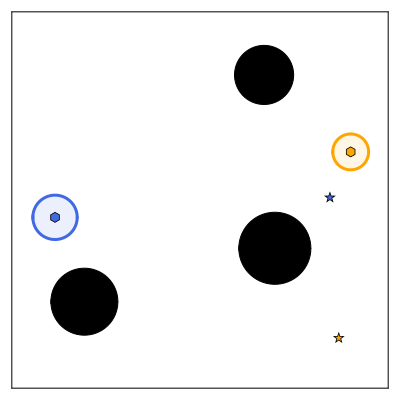

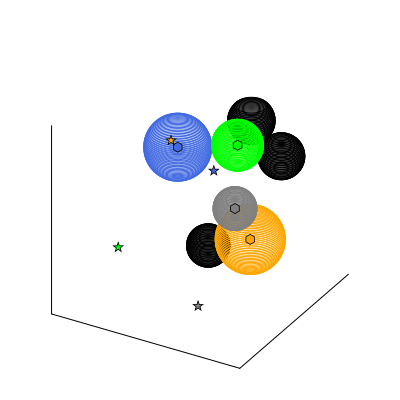

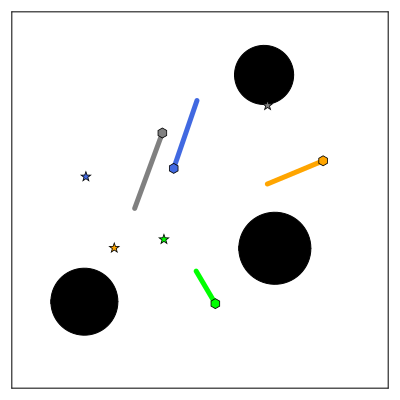

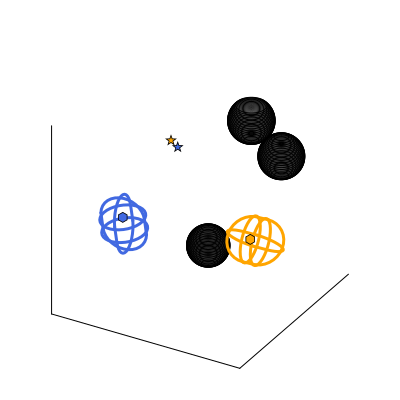

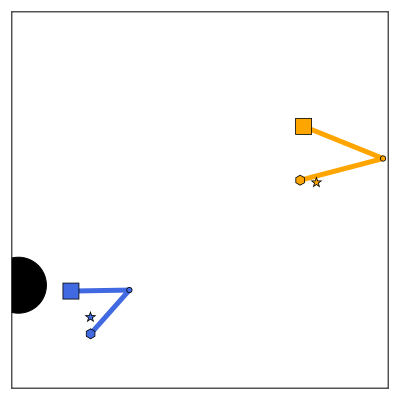

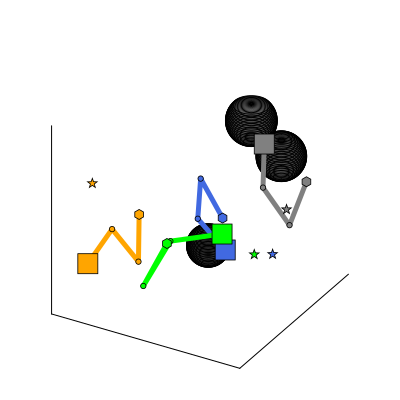

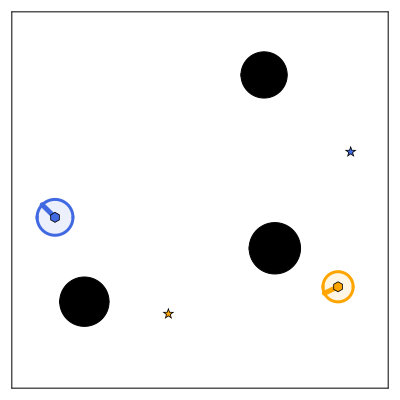

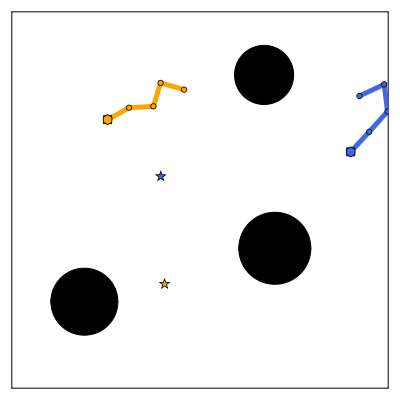

8-element Vector{String}:
 "../../data/benchmark/ijcai23/main/point2d_cost.csv"
 "../../data/benchmark/ijcai23/main/point3d_cost.csv"
 "../../data/benchmark/ijcai23/main/line2d_cost.csv"
 "../../data/benchmark/ijcai23/main/capsule3d_cost.csv"
 "../../data/benchmark/ijcai23/main/arm22_cost.csv"
 "../../data/benchmark/ijcai23/main/arm33_cost.csv"
 "../../data/benchmark/ijcai23/main/dubins2d_cost.csv"
 "../../data/benchmark/ijcai23/main/snake2d_cost.csv"

In [3]:
scenarios = ["point2d", "point3d", "line2d", "capsule3d", "arm22", "arm33", "dubins2d", "snake2d"]
make_cost_lb!.(scenarios)